# SaaS CHURN SIGNAL SYSTEM 🚀📊



##  OVERVIEW 📖  
This notebook contains two advanced analyses:  

---

## PART A — SURVIVAL ANALYSIS (Kaplan-Meier) ⏳📈  
- **WHEN** do customers churn?  

Unlike churn rate which gives one number,  
survival analysis shows the full journey —  
what % of customers survive at every point  
in time.  

---

## PART B — CUSTOMER SEGMENTATION (K-Means) 👥🎯  
-  **WHO** are our customers?  

Groups customers into distinct archetypes  
based on behaviour and billing patterns.  
Each segment gets a tailored retention  
strategy — not one-size-fits-all.  

---

In [4]:
pip install lifelines

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

import os
os.makedirs('reports', exist_ok=True)

In [6]:
# Load and clean data (same steps as Phase 3)
df = pd.read_csv('telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print("Data ready:", df.shape)
print("Churn rate:", f"{df['Churn_Binary'].mean()*100:.2f}%")

Data ready: (7032, 22)
Churn rate: 26.58%


# **SURVIVAL ANALYSIS**

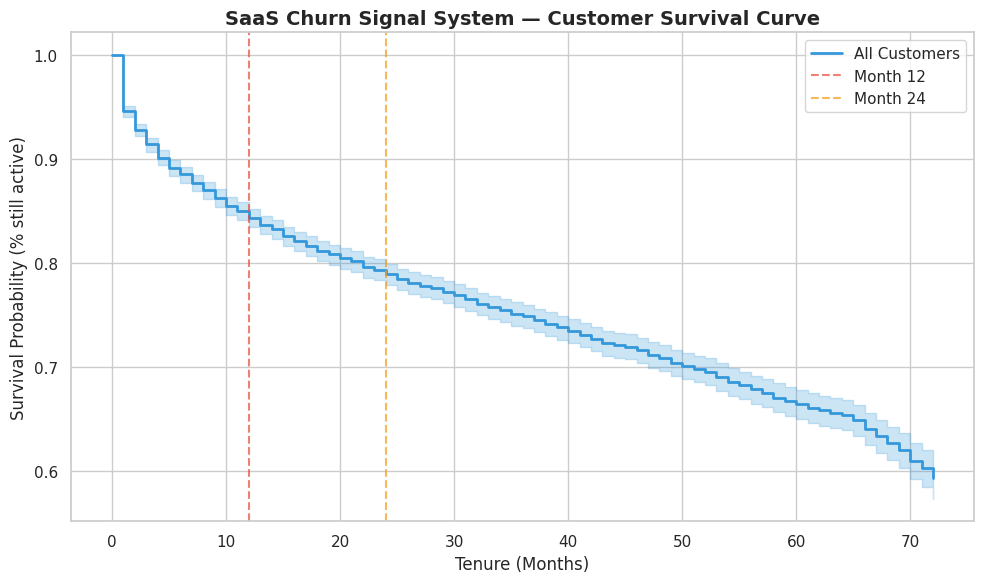

Survival probability at key milestones:
Month 6  : 88.48%
Month 12 : 84.32%
Month 24 : 78.87%
Month 48 : 70.88%


In [7]:
#Overall Survival Curve
kmf = KaplanMeierFitter()

# Fit the model
# duration = how long each customer stayed (tenure)
# event_observed = did they churn? (1=yes, 0=still active)
kmf.fit(
    durations=df['tenure'],
    event_observed=df['Churn_Binary'],
    label='All Customers'
)

# Plot
plt.figure(figsize=(10, 6))
kmf.plot_survival_function(
    ci_show=True,        # show confidence interval band
    color='#3498db',
    linewidth=2
)

# Add reference lines at key months
plt.axvline(x=12, color='#e74c3c', linestyle='--', alpha=0.7, label='Month 12')
plt.axvline(x=24, color='#f39c12', linestyle='--', alpha=0.7, label='Month 24')

plt.title('SaaS Churn Signal System — Customer Survival Curve',
          fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability (% still active)')
plt.legend()
plt.tight_layout()
plt.savefig('reports/05_survival_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# Print survival probabilities at key milestones
print("Survival probability at key milestones:")
print(f"Month 6  : {kmf.survival_function_at_times([6]).values[0]:.2%}")
print(f"Month 12 : {kmf.survival_function_at_times([12]).values[0]:.2%}")
print(f"Month 24 : {kmf.survival_function_at_times([24]).values[0]:.2%}")
print(f"Month 48 : {kmf.survival_function_at_times([48]).values[0]:.2%}")


### **Survival by Contract Type**

In [8]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

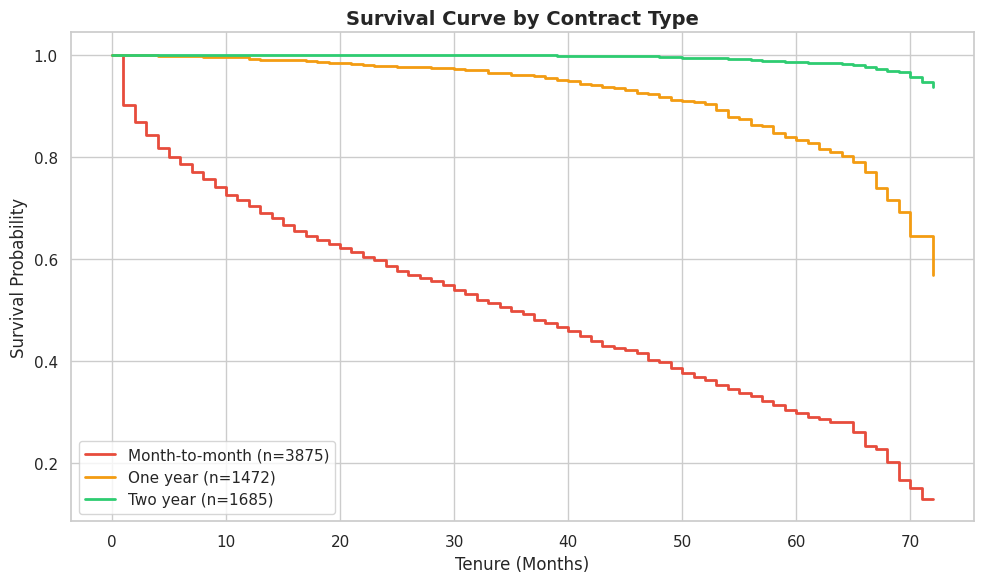

Median survival time by contract type:
Month-to-month      : 35.0 months
One year            : inf months
Two year            : inf months


In [9]:

plt.figure(figsize=(10, 6))

# Colors for each contract type
colors = {
    'Month-to-month' : '#e74c3c',
    'One year'       : '#f39c12',
    'Two year'       : '#2ecc71'
}

# Fit and plot one curve per contract type
for contract_type, color in colors.items():
    mask = df['Contract'] == contract_type
    kmf_group = KaplanMeierFitter()
    kmf_group.fit(
        durations=df[mask]['tenure'],
        event_observed=df[mask]['Churn_Binary'],
        label=f'{contract_type} (n={mask.sum()})'
    )
    kmf_group.plot_survival_function(
        ci_show=False,
        color=color,
        linewidth=2
    )

plt.title('Survival Curve by Contract Type',
          fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('reports/06_survival_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

# Print median survival per contract type
print("Median survival time by contract type:")
for contract_type in colors.keys():
    mask = df['Contract'] == contract_type
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df[mask]['tenure'], df[mask]['Churn_Binary'])
    median = kmf_temp.median_survival_time_
    print(f"{contract_type:20s}: {median} months")


## **SURVIVAL BY INTERNET SERVICE**

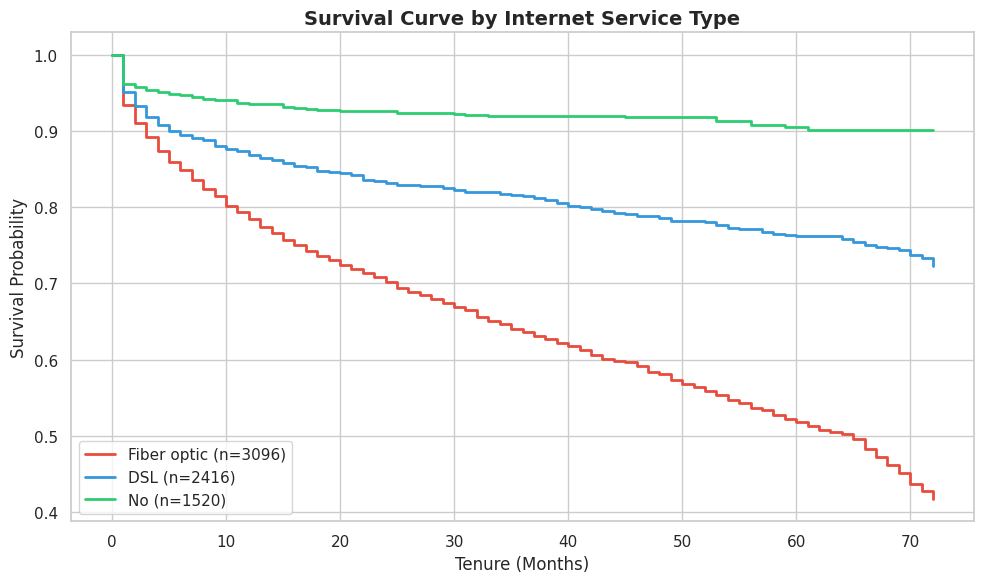

Churn rate by internet service:
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43


In [10]:

plt.figure(figsize=(10, 6))

colors2 = {
    'Fiber optic' : '#e74c3c',
    'DSL'         : '#3498db',
    'No'          : '#2ecc71'
}

for service, color in colors2.items():
    mask = df['InternetService'] == service
    kmf_group = KaplanMeierFitter()
    kmf_group.fit(
        durations=df[mask]['tenure'],
        event_observed=df[mask]['Churn_Binary'],
        label=f'{service} (n={mask.sum()})'
    )
    kmf_group.plot_survival_function(
        ci_show=False,
        color=color,
        linewidth=2
    )

plt.title('Survival Curve by Internet Service Type',
          fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Survival Probability')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('reports/07_survival_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

# Churn rates per group for context
print("Churn rate by internet service:")
print(df.groupby('InternetService')['Churn_Binary']
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
      .to_string())

In [11]:
# Fiber optic customers churn at 42% — more than double DSL customers. Despite paying the most

# **CUSTOMER SEGMENTATION**

In [12]:
# Select features that describe customer behaviour
features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Extract feature matrix
X = df[features].copy()

# Standardise — brings all features to same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected:", features)
print("Shape of feature matrix:", X_scaled.shape)
print("\nBefore scaling — MonthlyCharges range:")
print(f"  Min: {df['MonthlyCharges'].min():.2f}, Max: {df['MonthlyCharges'].max():.2f}")
print("\nAfter scaling — MonthlyCharges range:")
print(f"  Min: {X_scaled[:,1].min():.2f}, Max: {X_scaled[:,1].max():.2f}")

Features selected: ['tenure', 'MonthlyCharges', 'TotalCharges']
Shape of feature matrix: (7032, 3)

Before scaling — MonthlyCharges range:
  Min: 18.25, Max: 118.75

After scaling — MonthlyCharges range:
  Min: -1.55, Max: 1.79


### **Find Optimal Number of Clusters (Elbow Method)**

K=2 | Inertia: 9701 | Silhouette: 0.480
K=3 | Inertia: 6177 | Silhouette: 0.452
K=4 | Inertia: 4145 | Silhouette: 0.472
K=5 | Inertia: 3108 | Silhouette: 0.443
K=6 | Inertia: 2560 | Silhouette: 0.438
K=7 | Inertia: 2178 | Silhouette: 0.431
K=8 | Inertia: 1861 | Silhouette: 0.427
K=9 | Inertia: 1629 | Silhouette: 0.430
K=10 | Inertia: 1411 | Silhouette: 0.437


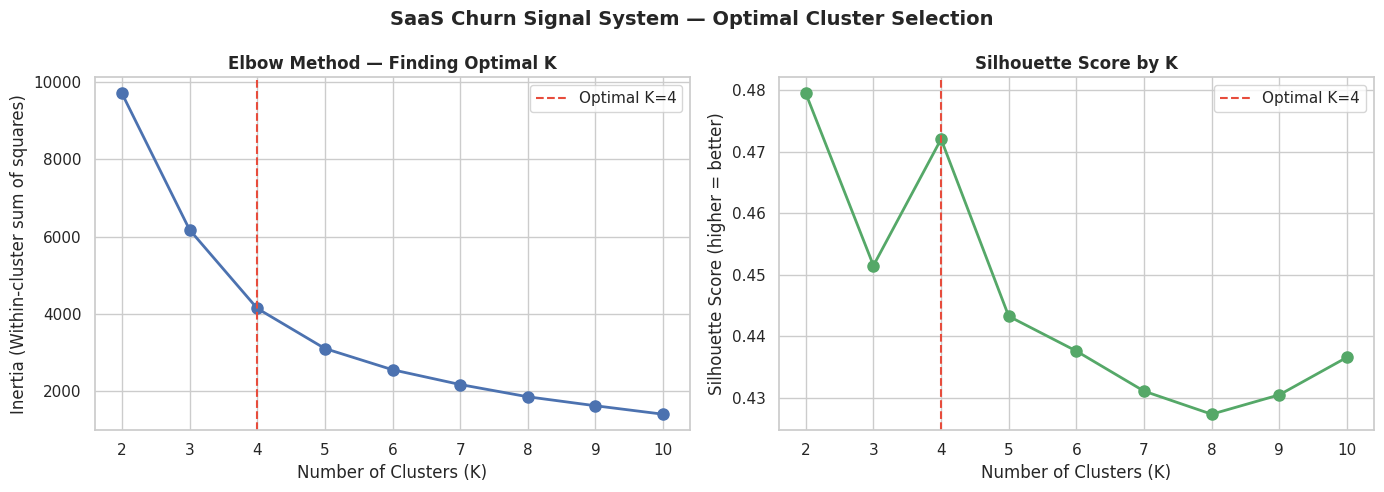

In [14]:


inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k} | Inertia: {kmeans.inertia_:.0f} | Silhouette: {silhouette_score(X_scaled, kmeans.labels_):.3f}")

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Finding Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].axvline(x=4, color='#e74c3c', linestyle='--', label='Optimal K=4')
axes[0].legend()

# Silhouette scores
axes[1].plot(k_range, silhouette_values, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score by K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].axvline(x=4, color='#e74c3c', linestyle='--', label='Optimal K=4')
axes[1].legend()

plt.suptitle('SaaS Churn Signal System — Optimal Cluster Selection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/08_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()


### **Build the 4 Customer Segments**

In [15]:

# Apply K-Means with optimal K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segment'] = kmeans_final.fit_predict(X_scaled)

# Profile each segment
segment_profile = df.groupby('Segment').agg(
    customer_count  = ('customerID', 'count'),
    avg_tenure      = ('tenure', 'mean'),
    avg_monthly     = ('MonthlyCharges', 'mean'),
    avg_total       = ('TotalCharges', 'mean'),
    churn_rate      = ('Churn_Binary', 'mean')
).round(2)

segment_profile['churn_rate_pct'] = (segment_profile['churn_rate'] * 100).round(1)
print("Segment profiles:")
print(segment_profile)


Segment profiles:
         customer_count  avg_tenure  avg_monthly  avg_total  churn_rate  \
Segment                                                                   
0                  1696       10.28        31.78     303.82        0.25   
1                  1904       59.53        93.31    5548.65        0.15   
2                  1159       53.59        34.92    1836.58        0.05   
3                  2273       15.45        80.79    1252.82        0.48   

         churn_rate_pct  
Segment                  
0                  25.0  
1                  15.0  
2                   5.0  
3                  48.0  


In [13]:
#Give each cluster a meaningful business name based on its profile.

In [16]:
# Based on profile — map each cluster to a name
# Low tenure + high churn = New At-Risk
# High tenure + low churn = Loyal Champions
# Mid tenure + mid churn = Stable Mid-Value
# High charges + mid churn = High Value At-Risk

segment_names = {
    0: 'New At-Risk',        # low tenure, high churn
    1: 'Loyal Champions',    # high tenure, low churn
    2: 'Stable Mid-Value',   # mid tenure, moderate churn
    3: 'High Value At-Risk'  # high charges, notable churn
}

df['Segment_Name'] = df['Segment'].map(segment_names)

# Final profile with names
final_profile = df.groupby('Segment_Name').agg(
    customers       = ('customerID', 'count'),
    avg_tenure      = ('tenure', 'mean'),
    avg_monthly_mrr = ('MonthlyCharges', 'mean'),
    churn_rate_pct  = ('Churn_Binary', lambda x: f"{x.mean()*100:.1f}%")
).round(2)

print("Named segment profiles:")
print(final_profile)
print("\nSegment distribution:")
print(df['Segment_Name'].value_counts())


Named segment profiles:
                    customers  avg_tenure  avg_monthly_mrr churn_rate_pct
Segment_Name                                                             
High Value At-Risk       2273       15.45            80.79          48.3%
Loyal Champions          1904       59.53            93.31          15.4%
New At-Risk              1696       10.28            31.78          24.8%
Stable Mid-Value         1159       53.59            34.92           5.0%

Segment distribution:
Segment_Name
High Value At-Risk    2273
Loyal Champions       1904
New At-Risk           1696
Stable Mid-Value      1159
Name: count, dtype: int64


### **Visualise the Segments**

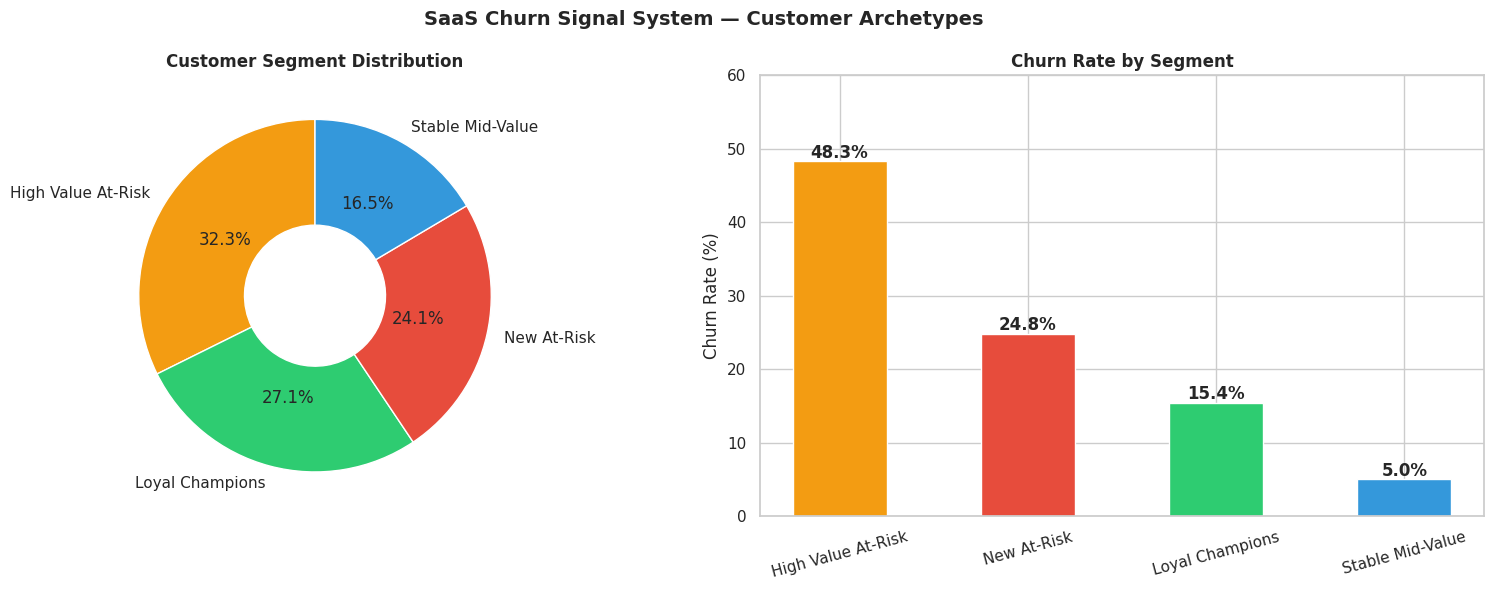


BUSINESS SUMMARY
High Value At-Risk        | 2273 customers | 48.3% churn | $183,638 MRR
New At-Risk               | 1696 customers | 24.8% churn | $53,895 MRR
Loyal Champions           | 1904 customers | 15.4% churn | $177,655 MRR
Stable Mid-Value          | 1159 customers | 5.0% churn | $40,472 MRR


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_seg = {
    'New At-Risk'        : '#e74c3c',
    'High Value At-Risk' : '#f39c12',
    'Stable Mid-Value'   : '#3498db',
    'Loyal Champions'    : '#2ecc71'
}

seg_counts = df['Segment_Name'].value_counts()
seg_churn  = df.groupby('Segment_Name')['Churn_Binary'].mean() * 100

# Donut chart — segment sizes
wedges, texts, autotexts = axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=[colors_seg[s] for s in seg_counts.index],
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title('Customer Segment Distribution', fontweight='bold')

# Bar chart — churn rate per segment
seg_churn_sorted = seg_churn.sort_values(ascending=False)
bars = axes[1].bar(
    seg_churn_sorted.index,
    seg_churn_sorted.values,
    color=[colors_seg[s] for s in seg_churn_sorted.index],
    edgecolor='white', width=0.5
)
axes[1].set_title('Churn Rate by Segment', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, seg_churn_sorted.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('SaaS Churn Signal System — Customer Archetypes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/09_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# Business summary
print("\nBUSINESS SUMMARY")
print("="*50)
for seg in seg_churn_sorted.index:
    count = seg_counts[seg]
    churn = seg_churn_sorted[seg]
    mrr   = df[df['Segment_Name']==seg]['MonthlyCharges'].sum()
    print(f"{seg:25s} | {count:4d} customers | {churn:.1f}% churn | ${mrr:,.0f} MRR")

In [18]:
# AUTHOR  : Sonu/seenuuu
# PROJECT : SaaS Churn Signal System